In [6]:
# ============================================================
# PASSO 1: Monta o Google Drive
# Sempre necessário ao iniciar nova sessão no Colab
# ============================================================

from google.colab import drive
drive.mount("/drive")

print("✅ Google Drive montado!")

Mounted at /drive
✅ Google Drive montado!


In [7]:
# ARQUITETURA: Camada de visualização (4/5)
# Transforma os resultados SQL em gráficos para o README

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os

# Estilo visual profissional para todos os gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Pasta para salvar os gráficos gerados
os.makedirs("/content/graficos", exist_ok=True)

print("✅ Bibliotecas carregadas!")



✅ Bibliotecas carregadas!


In [8]:
# ============================================================
# ENTRADA: Recarrega e prepara os dados do Drive
# Mesmo fluxo do notebook anterior — padrão do projeto
# ============================================================

df_raw = pd.read_csv(
    "/drive/MyDrive/INFLUD24.csv",
    sep=";",
    encoding="latin-1",
    low_memory=False
)

COLUNAS_RELEVANTES = [
    "DT_NOTIFIC", "SG_UF_NOT", "ID_MUNICIP",
    "NU_IDADE_N", "CS_SEXO", "CS_RACA", "CS_ESCOL_N",
    "CLASSI_FIN", "EVOLUCAO", "UTI", "SUPORT_VEN",
    "FEBRE", "TOSSE", "DISPNEIA", "SATURACAO", "VACINA_COV",
]

colunas_existentes = [c for c in COLUNAS_RELEVANTES if c in df_raw.columns]
df = df_raw[colunas_existentes].copy()

# Registra no DuckDB para reusar as queries
con = duckdb.connect()
con.register("srag", df)

print(f"✅ {df.shape[0]:,} linhas carregadas")

✅ 279,184 linhas carregadas


/tmp/ipykernel_221/3818205997.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


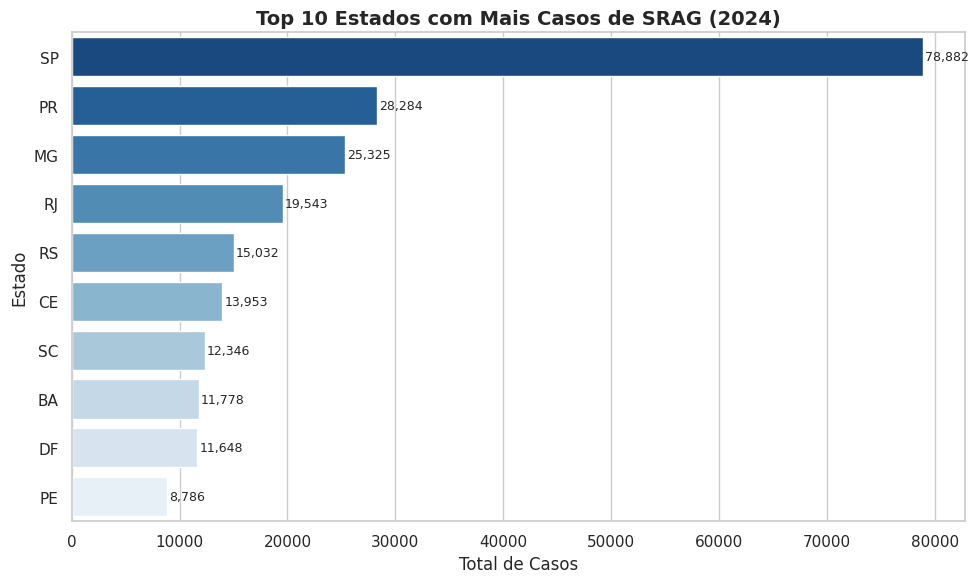

✅ Gráfico salvo!


In [9]:
# ============================================================
# GRÁFICO 1: Casos por estado
# Barplot horizontal — melhor para comparar categorias
# ============================================================

df_estados = con.execute("""
    SELECT SG_UF_NOT AS estado, COUNT(*) AS total_casos
    FROM srag
    WHERE SG_UF_NOT IS NOT NULL
    GROUP BY estado
    ORDER BY total_casos DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_estados,
    x="total_casos",
    y="estado",
    ax=ax,
    palette="Blues_r"
)

ax.set_title("Top 10 Estados com Mais Casos de SRAG (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total de Casos")
ax.set_ylabel("Estado")

# Adiciona os valores nas barras
for i, v in enumerate(df_estados["total_casos"]):
    ax.text(v + 200, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/graficos/01_casos_por_estado.png", dpi=150)
plt.show()
print("✅ Gráfico salvo!")

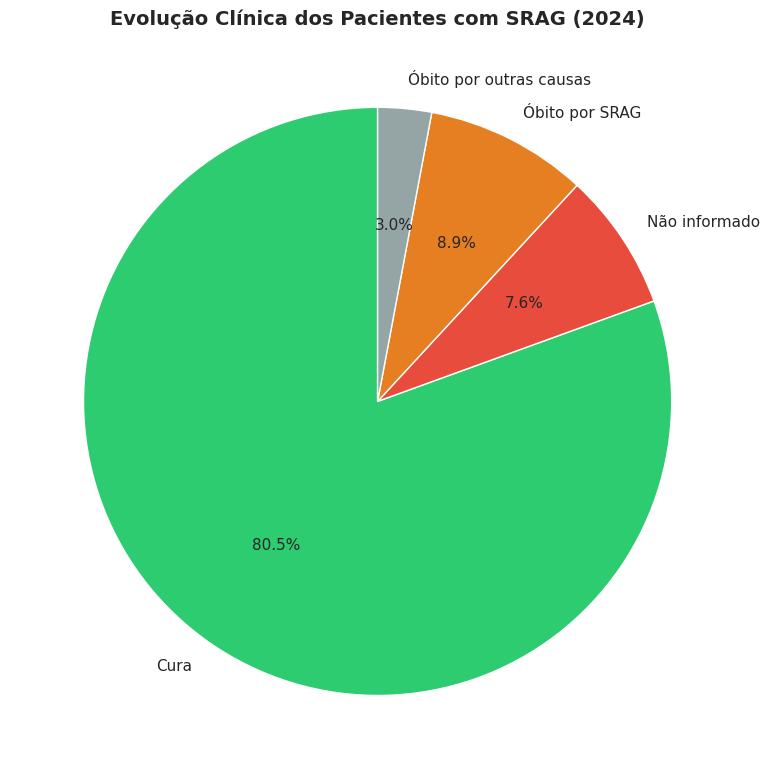

✅ Gráfico salvo!


In [10]:
# ============================================================
# GRÁFICO 2: Evolução clínica dos pacientes
# Pizza — ideal para mostrar proporção de desfechos
# ============================================================

df_evolucao = con.execute("""
    SELECT
        CASE CAST(EVOLUCAO AS VARCHAR)
            WHEN '1' THEN 'Cura'
            WHEN '2' THEN 'Óbito por SRAG'
            WHEN '3' THEN 'Óbito por outras causas'
            ELSE 'Não informado'
        END AS evolucao,
        COUNT(*) AS total
    FROM srag
    GROUP BY EVOLUCAO
    ORDER BY total DESC
""").df()

# Agrupa todos os "Não informado" em uma única fatia
df_evolucao = df_evolucao.groupby("evolucao", as_index=False)["total"].sum()

fig, ax = plt.subplots(figsize=(8, 8))

cores = ["#2ecc71", "#e74c3c", "#e67e22", "#95a5a6"]

ax.pie(
    df_evolucao["total"],
    labels=df_evolucao["evolucao"],
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
    textprops={"fontsize": 11}
)

ax.set_title("Evolução Clínica dos Pacientes com SRAG (2024)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("/content/graficos/02_evolucao_clinica.png", dpi=150)
plt.show()
print("✅ Gráfico salvo!")

/tmp/ipykernel_221/727769879.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


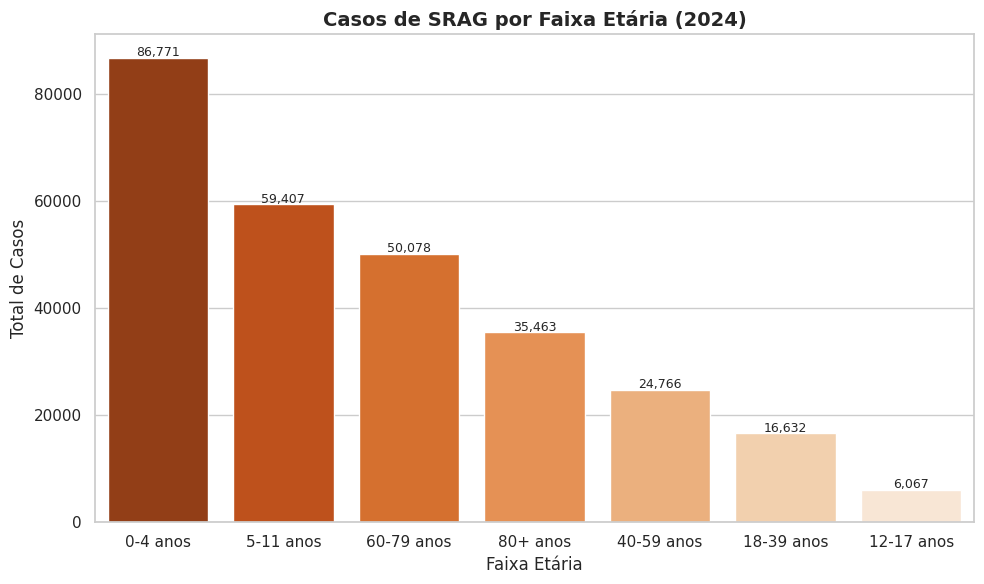

✅ Gráfico salvo!


In [11]:
# ============================================================
# GRÁFICO 3: Casos por faixa etária
# Barplot ordenado por faixa — revela padrão epidemiológico
# ============================================================

df_idade = con.execute("""
    SELECT
        CASE
            WHEN TRY_CAST(NU_IDADE_N AS INTEGER) < 5   THEN '0-4 anos'
            WHEN TRY_CAST(NU_IDADE_N AS INTEGER) < 12  THEN '5-11 anos'
            WHEN TRY_CAST(NU_IDADE_N AS INTEGER) < 18  THEN '12-17 anos'
            WHEN TRY_CAST(NU_IDADE_N AS INTEGER) < 40  THEN '18-39 anos'
            WHEN TRY_CAST(NU_IDADE_N AS INTEGER) < 60  THEN '40-59 anos'
            WHEN TRY_CAST(NU_IDADE_N AS INTEGER) < 80  THEN '60-79 anos'
            ELSE '80+ anos'
        END AS faixa_etaria,
        COUNT(*) AS total_casos
    FROM srag
    WHERE NU_IDADE_N IS NOT NULL
    GROUP BY faixa_etaria
    ORDER BY total_casos DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_idade,
    x="faixa_etaria",
    y="total_casos",
    ax=ax,
    palette="Oranges_r"
)

ax.set_title("Casos de SRAG por Faixa Etária (2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Faixa Etária")
ax.set_ylabel("Total de Casos")

# Adiciona os valores no topo das barras
for i, v in enumerate(df_idade["total_casos"]):
    ax.text(i, v + 300, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/graficos/03_faixa_etaria.png", dpi=150)
plt.show()
print("✅ Gráfico salvo!")